# AI-Based Smart Irrigation System Using Environmental Sensor Data

In [1]:
import json
import platform
import warnings
from datetime import datetime
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             classification_report, confusion_matrix,
                             precision_recall_fscore_support)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold,
                                     cross_val_predict, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier, export_text

warnings.filterwarnings("ignore")          # keep the report output clean
RANDOM_STATE = 42                          # reproducibility everywhere
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold"})
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
print("pandas", pd.__version__, "| numpy", np.__version__, "| scikit-learn", sklearn.__version__)

pandas 2.2.2 | numpy 1.26.4 | scikit-learn 1.5.1


# Load the dataset

In [2]:
CANDIDATE_PATHS = [
    "irrigation_prediction.csv",                          
    "/mnt/user-data/uploads/irrigation_prediction.csv",  
]
DATA_PATH = next((p for p in CANDIDATE_PATHS if Path(p).exists()), None)
assert DATA_PATH is not None, "Dataset not found - put irrigation_prediction.csv next to the notebook."

df_raw = pd.read_csv(DATA_PATH)
print("Loaded from:", DATA_PATH)
print("Shape (rows, columns):", df_raw.shape)

Loaded from: irrigation_prediction.csv
Shape (rows, columns): (10000, 20)


In [3]:
print("First 5 rows"); display(df_raw.head())
print("Last 5 rows");  display(df_raw.tail())

First 5 rows


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Clay,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,Wheat,Vegetative,Rabi,Rainfed,Reservoir,4.73,Yes,1.98,South,Low
1,Silt,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,Maize,Flowering,Zaid,Canal,Groundwater,12.22,Yes,33.56,Central,Medium
2,Sandy,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,Cotton,Harvest,Rabi,Drip,Reservoir,5.52,Yes,34.62,South,Low
3,Clay,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,Wheat,Sowing,Kharif,Canal,Reservoir,1.43,Yes,84.03,North,Medium
4,Clay,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,Cotton,Sowing,Zaid,Canal,River,2.52,No,60.86,South,Medium


Last 5 rows


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
9995,Silt,7.01,26.67,0.86,0.76,27.61,52.20,1075.12,7.41,19.66,Sugarcane,Sowing,Kharif,Drip,Groundwater,2.62,Yes,92.44,South,Low
9996,Clay,5.40,49.44,0.90,1.19,34.03,52.31,1591.84,9.86,5.66,Maize,Sowing,Kharif,Rainfed,Groundwater,4.87,No,15.46,South,Low
9997,Loamy,4.97,60.63,0.99,1.30,36.68,68.16,2384.87,10.75,13.40,Potato,Harvest,Kharif,Canal,Groundwater,10.08,Yes,116.36,North,Low
9998,Loamy,7.12,44.33,1.56,1.08,31.50,64.83,2397.01,4.03,3.05,Sugarcane,Harvest,Kharif,Rainfed,Reservoir,11.11,Yes,118.17,East,Low
9999,Sandy,5.65,62.25,1.48,3.00,35.71,45.33,177.69,10.93,12.32,Potato,Harvest,Kharif,Canal,Rainwater,11.32,No,98.88,North,Medium


In [4]:
print("Column names:"); print(df_raw.columns.tolist()); print()
df_raw.info()

Column names:
['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare', 'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Soil_Type                10000 non-null  object 
 1   Soil_pH                  10000 non-null  float64
 2   Soil_Moisture            10000 non-null  float64
 3   Organic_Carbon           10000 non-null  float64
 4   Electrical_Conductivity  10000 non-null  float64
 5   Temperature_C            10000 non-null  float64
 6   Humidity                 10000 non-null  float64
 7   Rainfall_mm              10000 non-null  float

### Overview: types, missing values, duplicates, unique values

In [5]:
numeric_cols = df_raw.select_dtypes(include="number").columns.tolist()
categorical_cols = df_raw.select_dtypes(exclude="number").columns.tolist()

print(f"Observations (rows)      : {len(df_raw):,}")
print(f"Variables (columns)      : {df_raw.shape[1]}")
print(f"Numerical columns  ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical columns({len(categorical_cols)}): {categorical_cols}")
print(f"Total missing values     : {int(df_raw.isna().sum().sum())}")
print(f"Duplicate rows           : {int(df_raw.duplicated().sum())}")

overview = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing": df_raw.isna().sum(),
    "unique_values": df_raw.nunique(),
})
display(overview)

Observations (rows)      : 10,000
Variables (columns)      : 20
Numerical columns  (11): ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']
Categorical columns(9): ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region', 'Irrigation_Need']
Total missing values     : 0
Duplicate rows           : 0


,dtype,missing,unique_values
Soil_Type,object,0,4
Soil_pH,float64,0,341
Soil_Moisture,float64,0,4751
Organic_Carbon,float64,0,131
Electrical_Conductivity,float64,0,341
Temperature_C,float64,0,2897
Humidity,float64,0,5305
Rainfall_mm,float64,0,9813
Sunlight_Hours,float64,0,701
Wind_Speed_kmh,float64,0,1937


In [6]:
display(df_raw.describe().T.round(2))
print("Categorical variables - category counts:")
for col in categorical_cols:
    print(f"  {col:18s}", df_raw[col].value_counts().to_dict())

,count,mean,std,min,25%,50%,75%,max
Soil_pH,10000.0,6.49,0.98,4.80,5.64,6.47,7.35,8.20
Soil_Moisture,10000.0,36.97,16.43,8.00,22.86,37.24,50.94,65.00
Organic_Carbon,10000.0,0.94,0.37,0.30,0.62,0.95,1.26,1.60
Electrical_Conductivity,10000.0,1.79,0.98,0.10,0.94,1.78,2.65,3.50
Temperature_C,10000.0,26.99,8.66,12.00,19.46,27.09,34.50,42.00
Humidity,10000.0,60.08,20.19,25.00,42.86,60.04,77.70,95.00
Rainfall_mm,10000.0,1252.50,715.58,0.38,634.16,1250.34,1880.26,2499.69
Sunlight_Hours,10000.0,7.52,2.02,4.00,5.76,7.56,9.26,11.00
Wind_Speed_kmh,10000.0,10.16,5.67,0.50,5.16,10.19,15.10,20.00
Field_Area_hectare,10000.0,7.60,4.23,0.30,3.95,7.54,11.20,15.00


Categorical variables - category counts:
  Soil_Type          {'Sandy': 2536, 'Silt': 2501, 'Loamy': 2486, 'Clay': 2477}
  Crop_Type          {'Rice': 1711, 'Maize': 1694, 'Sugarcane': 1678, 'Potato': 1663, 'Wheat': 1659, 'Cotton': 1595}
  Crop_Growth_Stage  {'Harvest': 2581, 'Vegetative': 2521, 'Flowering': 2465, 'Sowing': 2433}
  Season             {'Rabi': 3383, 'Kharif': 3362, 'Zaid': 3255}
  Irrigation_Type    {'Sprinkler': 2527, 'Rainfed': 2511, 'Drip': 2495, 'Canal': 2467}
  Water_Source       {'River': 2528, 'Reservoir': 2513, 'Rainwater': 2497, 'Groundwater': 2462}
  Mulching_Used      {'No': 5013, 'Yes': 4987}
  Region             {'South': 2102, 'West': 2017, 'East': 1994, 'Central': 1987, 'North': 1900}
  Irrigation_Need    {'Low': 5864, 'Medium': 3800, 'High': 336}


In [7]:
SOIL_COL, TEMP_COL, HUM_COL = "Soil_Moisture", "Temperature_C", "Humidity"
TARGET_COL = "Irrigation_Need"
FEATURES = [SOIL_COL, TEMP_COL, HUM_COL]           # final model inputs (order matters!)
CLASS_ORDER = ["Low", "Medium", "High"]            # natural order of the target labels
OTHER_COLS = [c for c in df_raw.columns if c not in FEATURES + [TARGET_COL]]

print("FEATURE COLUMNS :", FEATURES)
print("TARGET COLUMN   :", TARGET_COL, "->", CLASS_ORDER)
print("Documented but NOT used in the model:", OTHER_COLS)

FEATURE COLUMNS : ['Soil_Moisture', 'Temperature_C', 'Humidity']
TARGET COLUMN   : Irrigation_Need -> ['Low', 'Medium', 'High']
Documented but NOT used in the model: ['Soil_Type', 'Soil_pH', 'Organic_Carbon', 'Electrical_Conductivity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare', 'Mulching_Used', 'Previous_Irrigation_mm', 'Region']


In [8]:
summary = df_raw[FEATURES].agg(["count", "mean", "median", "std", "min", "max", "skew"]).T.round(2)
display(summary)

,count,mean,median,std,min,max,skew
Soil_Moisture,10000.0,36.97,37.24,16.43,8.0,65.0,-0.04
Temperature_C,10000.0,26.99,27.09,8.66,12.0,42.0,-0.01
Humidity,10000.0,60.08,60.04,20.19,25.0,95.0,-0.01


# Data cleaning

In [9]:
# 5.1 missing values, duplicates, types

print("Missing values in model columns:\n", df_raw[FEATURES + [TARGET_COL]].isna().sum().to_string(), "\n")
print("Duplicate rows:", df_raw.duplicated().sum())

print("Numeric feature dtypes:", df_raw[FEATURES].dtypes.astype(str).to_dict())

print("Target labels found   :", sorted(df_raw[TARGET_COL].dropna().unique()), "(expected", CLASS_ORDER, ")")

print("Labels with stray whitespace/case issues:",
      int((df_raw[TARGET_COL].dropna() != df_raw[TARGET_COL].dropna().str.strip().str.title()).sum()))

Missing values in model columns:
 Soil_Moisture      0
Temperature_C      0
Humidity           0
Irrigation_Need    0 

Duplicate rows: 0
Numeric feature dtypes: {'Soil_Moisture': 'float64', 'Temperature_C': 'float64', 'Humidity': 'float64'}
Target labels found   : ['High', 'Low', 'Medium'] (expected ['Low', 'Medium', 'High'] )
Labels with stray whitespace/case issues: 0


In [10]:
# 5.2 impossible values 

PHYSICAL_LIMITS = {SOIL_COL: (0, 100), TEMP_COL: (-20, 60), HUM_COL: (0, 100)}
rows = []
for col, (lo, hi) in PHYSICAL_LIMITS.items():
    rows.append({"variable": col, "allowed_range": f"{lo} to {hi}",
                 "observed_min": df_raw[col].min(), "observed_max": df_raw[col].max(),
                 "violations": int(((df_raw[col] < lo) | (df_raw[col] > hi)).sum())})
display(pd.DataFrame(rows))

,variable,allowed_range,observed_min,observed_max,violations
0,Soil_Moisture,0 to 100,8.0,65.0,0
1,Temperature_C,-20 to 60,12.0,42.0,0
2,Humidity,0 to 100,25.0,95.0,0


In [11]:
# 5.3 statistical outliers (IQR rule) - flagged only 

def iqr_outlier_report(frame, cols):
    out = []
    for col in cols:
        q1, q3 = frame[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        out.append({"variable": col, "lower_fence": round(lo, 2), "upper_fence": round(hi, 2),
                    "n_outliers": int(((frame[col] < lo) | (frame[col] > hi)).sum()),
                    "rows_at_min": int((frame[col] == frame[col].min()).sum()),
                    "rows_at_max": int((frame[col] == frame[col].max()).sum())})
    return pd.DataFrame(out)

display(iqr_outlier_report(df_raw, FEATURES))

,variable,lower_fence,upper_fence,n_outliers,rows_at_min,rows_at_max
0,Soil_Moisture,-19.26,93.06,0,1,1
1,Temperature_C,-3.10,57.06,0,1,2
2,Humidity,-9.42,129.98,0,2,1


In [12]:
# 5.4 apply cleaning (only what is justified) 

df = df_raw.copy()
before = df.shape
df = df.drop_duplicates()                                             
df = df.dropna(subset=FEATURES + [TARGET_COL])                        
df = df[np.logical_and.reduce([df[c].between(lo, hi) for c, (lo, hi) in PHYSICAL_LIMITS.items()])]  
df = df.reset_index(drop=True)

pd.DataFrame({"before": before, "after": df.shape}, index=["rows", "columns"]).T.pipe(display)
print("Rows removed:", before[0] - df.shape[0])

,rows,columns
before,10000,20
after,10000,20


Rows removed: 0


## Exploratory Data Analysis

All plots below use the cleaned dataframe `df`.


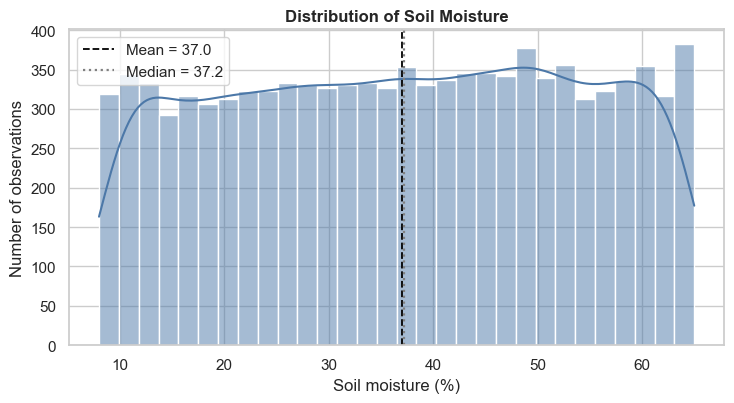

In [13]:
FEATURE_LABELS = {
    SOIL_COL: "Soil moisture (%)",
    TEMP_COL: "Temperature (°C)",
    HUM_COL: "Relative humidity (%)",
}
FEATURE_TITLES = {SOIL_COL: "Soil Moisture", TEMP_COL: "Temperature", HUM_COL: "Humidity"}
CLASS_COLORS = {"Low": "#4C9F70", "Medium": "#E9A23B", "High": "#C8443A"}

def plot_distribution(col, color):
    """Histogram + KDE + mean/median markers for one sensor variable."""
    
    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    sns.histplot(df[col], bins=30, kde=True, color=color, ax=ax)
    ax.axvline(df[col].mean(), color="black", ls="--", lw=1.3, label=f"Mean = {df[col].mean():.1f}")
    ax.axvline(df[col].median(), color="grey", ls=":", lw=1.6, label=f"Median = {df[col].median():.1f}")
    ax.set_title(f"Distribution of {FEATURE_TITLES[col]}")
    ax.set_xlabel(FEATURE_LABELS[col]); ax.set_ylabel("Number of observations")
    ax.legend(); plt.tight_layout(); plt.show()

plot_distribution(SOIL_COL, "#4C78A8")

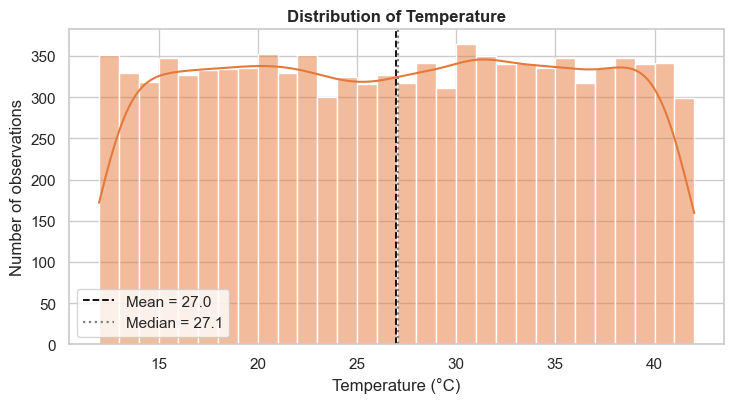

In [14]:
plot_distribution(TEMP_COL, "#E4793B")

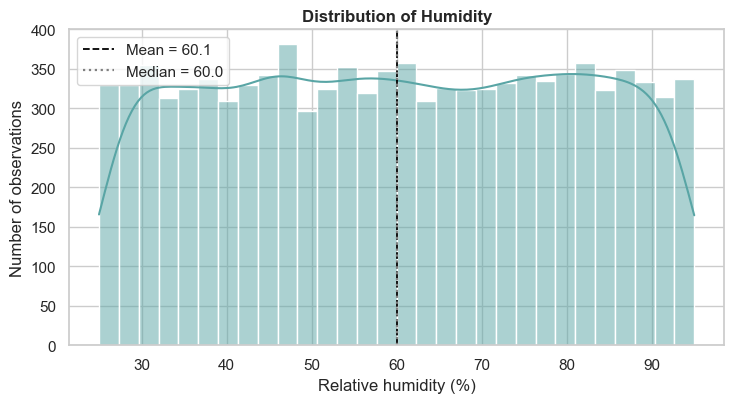

In [15]:
plot_distribution(HUM_COL, "#59A5A5")

In [16]:
# Are the distributions flat? Compare counts in 10 equal-width bins.

flat = {c: np.histogram(df[c], bins=10)[0] for c in FEATURES}
for c, counts in flat.items():
    print(f"{c:14s} bin counts: {counts.tolist()}  (max/min = {counts.max()/counts.min():.2f})")
print()
print("Pairwise correlation between the three sensor variables:")
display(df[FEATURES].corr().round(3))

Soil_Moisture  bin counts: [997, 914, 958, 991, 990, 1020, 1034, 1072, 974, 1050]  (max/min = 1.17)
Temperature_C  bin counts: [998, 1007, 1021, 980, 968, 969, 1054, 1024, 999, 980]  (max/min = 1.09)
Humidity       bin counts: [1015, 974, 982, 1003, 1020, 992, 979, 1021, 1029, 985]  (max/min = 1.06)

Pairwise correlation between the three sensor variables:


,Soil_Moisture,Temperature_C,Humidity
Soil_Moisture,1.000,-0.005,0.007
Temperature_C,-0.005,1.000,-0.009
Humidity,0.007,-0.009,1.000


# Correlation map

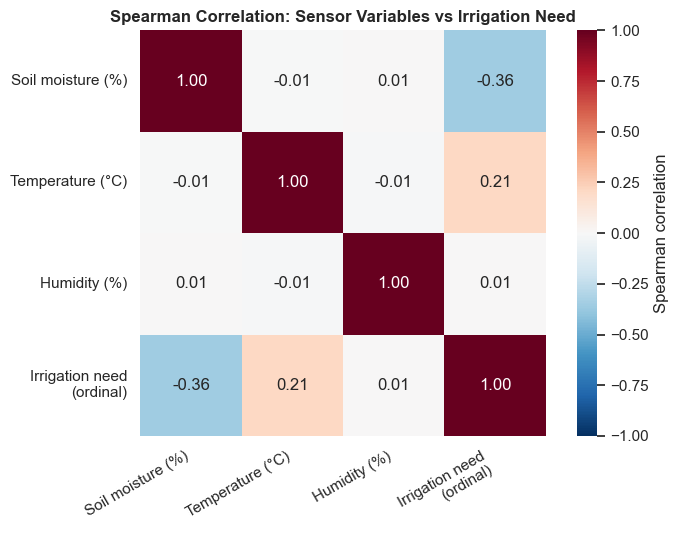

In [17]:
TARGET_ORDINAL = {label: i for i, label in enumerate(CLASS_ORDER)}   # Low=0, Medium=1, High=2
corr_frame = df[FEATURES].copy()
corr_frame["Irrigation_Need (Low=0, Med=1, High=2)"] = df[TARGET_COL].map(TARGET_ORDINAL)
corr = corr_frame.corr(method="spearman")

fig, ax = plt.subplots(figsize=(7.5, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, square=True, ax=ax,
            cbar_kws={"label": "Spearman correlation"})
ax.set_title("Spearman Correlation: Sensor Variables vs Irrigation Need")
ax.set_xticklabels(["Soil moisture (%)", "Temperature (°C)", "Humidity (%)", "Irrigation need\n(ordinal)"], rotation=30, ha="right")
ax.set_yticklabels(["Soil moisture (%)", "Temperature (°C)", "Humidity (%)", "Irrigation need\n(ordinal)"], rotation=0)
plt.tight_layout(); plt.show()

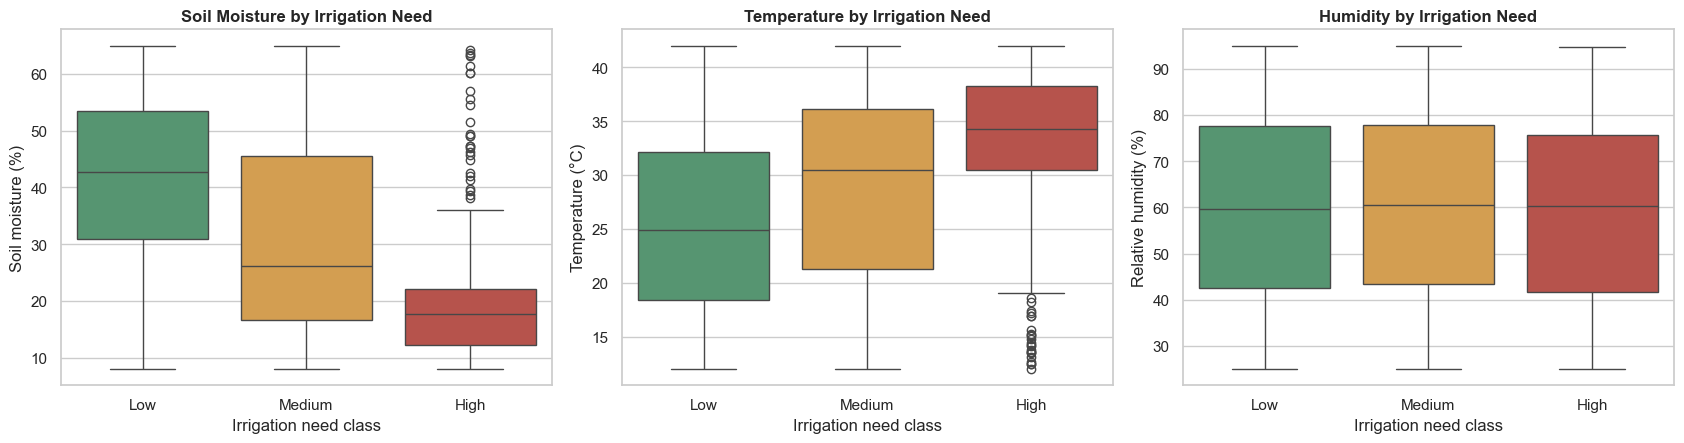

Mean of each sensor variable per class:


Soil_Moisture        Temperature_C       Humidity       
                         mean    std          mean   std     mean    std
Irrigation_Need                                                         
Low                     41.72  14.44         25.54  8.41    59.97  20.26
Medium                  31.16  16.83         28.71  8.64    60.32  20.09
High                    19.71  10.84         32.88  7.18    59.31  20.07

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
for ax, col in zip(axes, FEATURES):
    sns.boxplot(data=df, x=TARGET_COL, y=col, order=CLASS_ORDER, palette=CLASS_COLORS, ax=ax)
    ax.set_title(f"{FEATURE_TITLES[col]} by Irrigation Need")
    ax.set_xlabel("Irrigation need class"); ax.set_ylabel(FEATURE_LABELS[col])
plt.tight_layout(); plt.show()

print("Mean of each sensor variable per class:")
display(df.groupby(TARGET_COL)[FEATURES].agg(["mean", "std"]).reindex(CLASS_ORDER).round(2))

# Feature and target

In [19]:
X = df[FEATURES].copy()
y = df[TARGET_COL].copy()
print("X shape:", X.shape, "| y shape:", y.shape)
print("Feature order:", list(X.columns))
display(X.head(3))
print("Target classes:", CLASS_ORDER, "(Low = little/no irrigation needed, High = urgent irrigation need)")

X shape: (10000, 3) | y shape: (10000,)
Feature order: ['Soil_Moisture', 'Temperature_C', 'Humidity']


,Soil_Moisture,Temperature_C,Humidity
0,36.48,21.90,31.19
1,50.56,36.50,26.01
2,40.07,41.83,76.41


Target classes: ['Low', 'Medium', 'High'] (Low = little/no irrigation needed, High = urgent irrigation need)


,count,percent
Irrigation_Need,,
Low,5864,58.64
Medium,3800,38.00
High,336,3.36


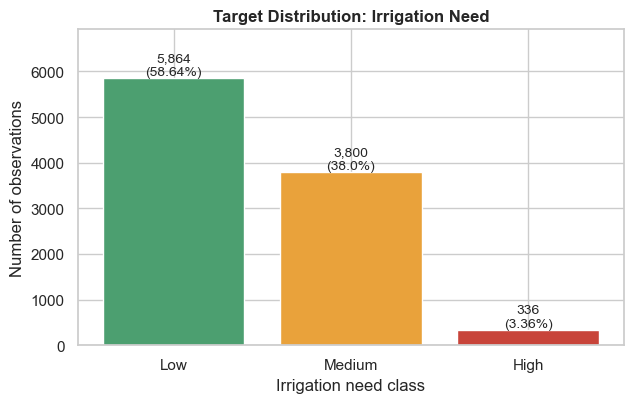

Imbalance ratio (largest / smallest class): 17.5 : 1


In [20]:
class_counts = y.value_counts().reindex(CLASS_ORDER)
class_pct = (class_counts / class_counts.sum() * 100).round(2)
display(pd.DataFrame({"count": class_counts, "percent": class_pct}))

fig, ax = plt.subplots(figsize=(6.5, 4.2))
bars = ax.bar(CLASS_ORDER, class_counts.values, color=[CLASS_COLORS[c] for c in CLASS_ORDER])
for bar, pct in zip(bars, class_pct):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 60, f"{int(bar.get_height()):,}\n({pct}%)", ha="center", fontsize=10)
ax.set_title("Target Distribution: Irrigation Need"); ax.set_xlabel("Irrigation need class")
ax.set_ylabel("Number of observations"); ax.set_ylim(0, class_counts.max() * 1.18)
plt.tight_layout(); plt.show()
print(f"Imbalance ratio (largest / smallest class): {class_counts.max() / class_counts.min():.1f} : 1")

# Train/test split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

print(f"Training set: {X_train.shape[0]:,} rows | Test set: {X_test.shape[0]:,} rows")
split_check = pd.DataFrame({
    "train_%": (y_train.value_counts(normalize=True).reindex(CLASS_ORDER) * 100).round(2),
    "test_%":  (y_test.value_counts(normalize=True).reindex(CLASS_ORDER) * 100).round(2),
    "train_n": y_train.value_counts().reindex(CLASS_ORDER),
    "test_n":  y_test.value_counts().reindex(CLASS_ORDER)})
display(split_check)

Training set: 8,000 rows | Test set: 2,000 rows


,train_%,test_%,train_n,test_n
Irrigation_Need,,,,
Low,58.64,58.65,4691,1173
Medium,38.00,38.00,3040,760
High,3.36,3.35,269,67


# Feature Scaling

In [22]:
def build_pipeline(model, scale):
    """Scaler (or passthrough) + model in one object -> no leakage, one object to deploy."""
    return Pipeline([("scaler", StandardScaler() if scale else "passthrough"),
                     ("clf", model)])

# Quick demonstration that the scaler learns from the training data only
demo_scaler = StandardScaler().fit(X_train)
print("Scaler means learned from TRAINING data:", dict(zip(FEATURES, demo_scaler.mean_.round(2))))
print("Scaler std devs learned from TRAINING data:", dict(zip(FEATURES, demo_scaler.scale_.round(2))))

Scaler means learned from TRAINING data: {'Soil_Moisture': 37.14, 'Temperature_C': 27.02, 'Humidity': 60.24}
Scaler std devs learned from TRAINING data: {'Soil_Moisture': 16.45, 'Temperature_C': 8.63, 'Humidity': 20.14}


# Train Multiple Candidate Models

In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

candidate_specs = {
    "Logistic Regression": dict(
        pipe=build_pipeline(LogisticRegression(max_iter=2000, random_state=RANDOM_STATE), scale=True),
        grid={"clf__C": [0.01, 0.1, 1, 10, 100]}),
    "Logistic Regression (balanced)": dict(
        pipe=build_pipeline(LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE), scale=True),
        grid={"clf__C": [0.01, 0.1, 1, 10, 100]}),
    "Decision Tree": dict(
        pipe=build_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE), scale=False),
        grid={"clf__max_depth": [2, 3, 4, 5, 6, 8, 10], "clf__min_samples_leaf": [5, 20, 50]}),
    "Decision Tree (balanced)": dict(
        pipe=build_pipeline(DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE), scale=False),
        grid={"clf__max_depth": [2, 3, 4, 5, 6, 8, 10], "clf__min_samples_leaf": [5, 20, 50]}),
    "Random Forest": dict(
        pipe=build_pipeline(RandomForestClassifier(n_estimators=150, random_state=RANDOM_STATE, n_jobs=1), scale=False),
        grid={"clf__max_depth": [4, 6, 8], "clf__min_samples_leaf": [10, 30], "clf__max_features": [1, 2]}),
    "Random Forest (balanced)": dict(
        pipe=build_pipeline(RandomForestClassifier(n_estimators=150, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1), scale=False),
        grid={"clf__max_depth": [4, 6, 8], "clf__min_samples_leaf": [10, 30], "clf__max_features": [1, 2]}),
}

fitted_models, best_params = {}, {}
for name, spec in candidate_specs.items():
    search = GridSearchCV(spec["pipe"], spec["grid"], scoring="f1_macro", cv=cv, n_jobs=1, refit=True)
    search.fit(X_train, y_train)                       # TRAINING DATA ONLY
    fitted_models[name] = search.best_estimator_
    best_params[name] = {k.replace("clf__", ""): v for k, v in search.best_params_.items()}
    print(f"{name:34s} best CV macro-F1 = {search.best_score_:.4f}  params = {best_params[name]}")

Logistic Regression                best CV macro-F1 = 0.4320  params = {'C': 0.1}
Logistic Regression (balanced)     best CV macro-F1 = 0.4315  params = {'C': 1}
Decision Tree                      best CV macro-F1 = 0.4639  params = {'max_depth': 4, 'min_samples_leaf': 5}
Decision Tree (balanced)           best CV macro-F1 = 0.5114  params = {'max_depth': 2, 'min_samples_leaf': 5}
Random Forest                      best CV macro-F1 = 0.4492  params = {'max_depth': 8, 'max_features': 2, 'min_samples_leaf': 30}
Random Forest (balanced)           best CV macro-F1 = 0.5095  params = {'max_depth': 6, 'max_features': 1, 'min_samples_leaf': 10}


# Evaluate the Models

In [24]:
def summarize(y_true, y_pred):
    """Overall + per-class metrics for the 3-class problem."""
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, labels=CLASS_ORDER, zero_division=0)
    out = {"accuracy": accuracy_score(y_true, y_pred),
           "macro_precision": p.mean(), "macro_recall": r.mean(), "macro_f1": f.mean()}
    for i, label in enumerate(CLASS_ORDER):
        out[f"precision_{label}"], out[f"recall_{label}"], out[f"f1_{label}"] = p[i], r[i], f[i]
    return out

test_predictions = {name: model.predict(X_test) for name, model in fitted_models.items()}
test_results = pd.DataFrame({name: summarize(y_test, pred) for name, pred in test_predictions.items()}).T
display(test_results[["accuracy", "macro_precision", "macro_recall", "macro_f1",
                      "precision_High", "recall_High", "f1_High"]].round(3))

,accuracy,macro_precision,macro_recall,macro_f1,precision_High,recall_High,f1_High
Logistic Regression,0.662,0.426,0.434,0.428,0.000,0.000,0.000
Logistic Regression (balanced),0.512,0.421,0.551,0.407,0.109,0.716,0.190
Decision Tree,0.695,0.519,0.457,0.455,0.200,0.015,0.028
Decision Tree (balanced),0.578,0.484,0.595,0.489,0.177,0.642,0.277
Random Forest,0.698,0.453,0.456,0.450,0.000,0.000,0.000
Random Forest (balanced),0.590,0.477,0.589,0.489,0.174,0.627,0.272


In [25]:
print("Per-class precision / recall / F1 on the test set")
per_class = test_results[[f"{m}_{c}" for c in CLASS_ORDER for m in ("precision", "recall", "f1")]].round(3)
per_class.columns = pd.MultiIndex.from_product([CLASS_ORDER, ["precision", "recall", "f1"]])
display(per_class)

Per-class precision / recall / F1 on the test set


Low                  Medium                    High              
                               precision recall     f1 precision recall     f1 precision recall     f1
Logistic Regression                0.704  0.808  0.753     0.573  0.493  0.530     0.000  0.000  0.000
Logistic Regression (balanced)     0.747  0.641  0.690     0.406  0.296  0.342     0.109  0.716  0.190
Decision Tree                      0.721  0.870  0.788     0.637  0.484  0.550     0.200  0.015  0.028
Decision Tree (balanced)           0.807  0.591  0.682     0.468  0.553  0.507     0.177  0.642  0.277
Random Forest                      0.725  0.863  0.788     0.635  0.505  0.563     0.000  0.000  0.000
Random Forest (balanced)           0.778  0.655  0.711     0.480  0.487  0.483     0.174  0.627  0.272

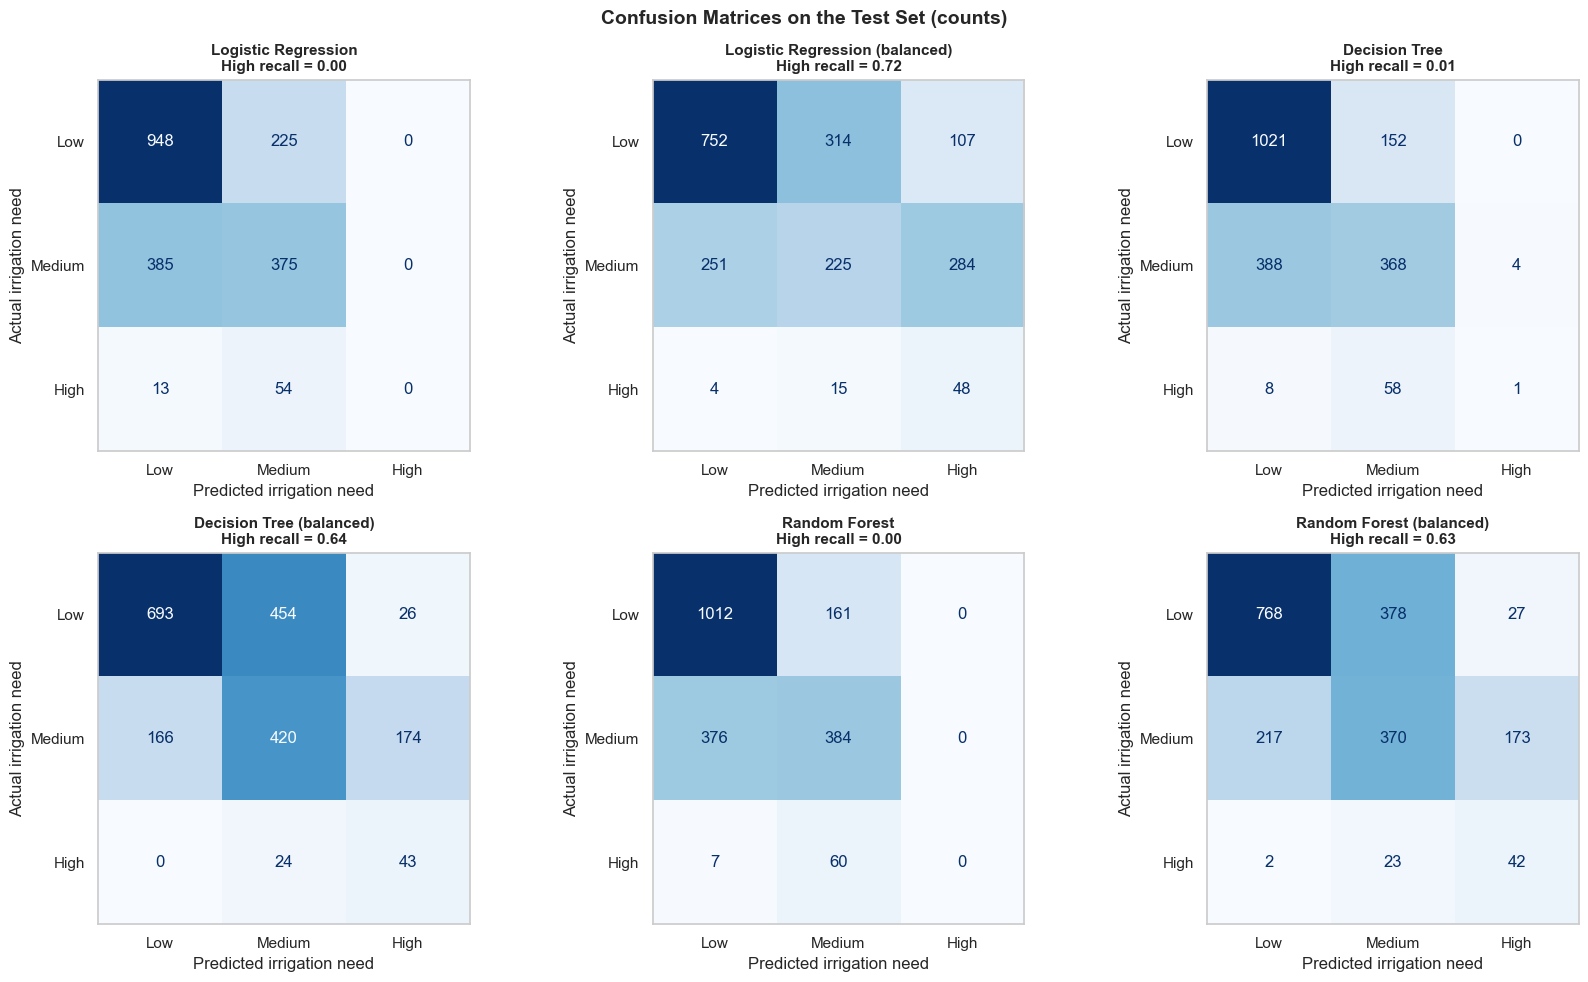

In [26]:
# Confusion matrices for all candidates (rows = actual, columns = predicted)

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
for ax, (name, pred) in zip(axes.ravel(), test_predictions.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, pred, labels=CLASS_ORDER, cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(f"{name}\nHigh recall = {test_results.loc[name, 'recall_High']:.2f}", fontsize=11)
    ax.set_xlabel("Predicted irrigation need"); ax.set_ylabel("Actual irrigation need"); ax.grid(False)
plt.suptitle("Confusion Matrices on the Test Set (counts)", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

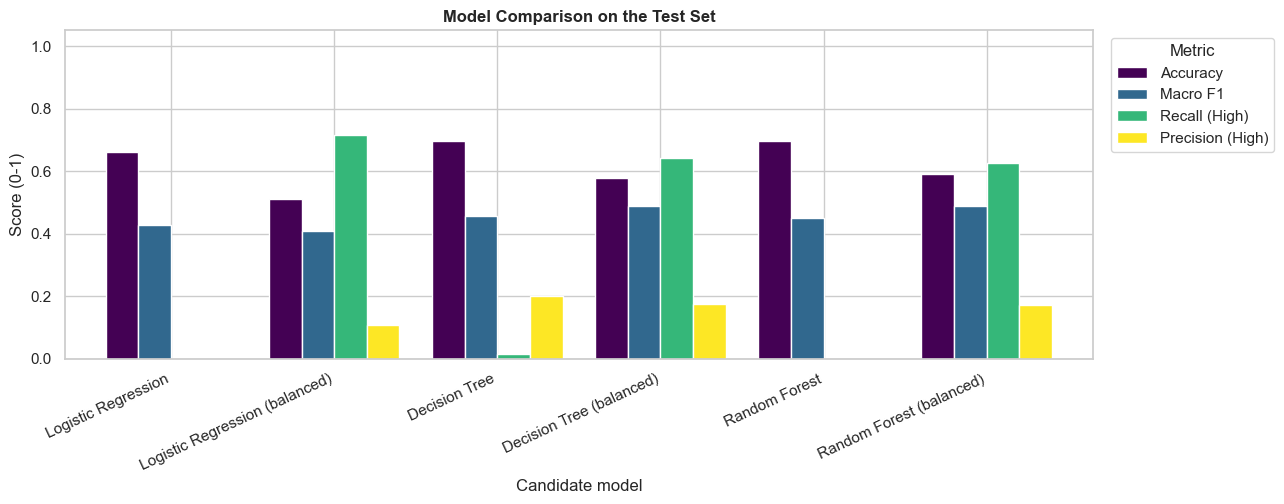

In [27]:
# Model comparison chart

plot_cols = {"accuracy": "Accuracy", "macro_f1": "Macro F1", "recall_High": "Recall (High)", "precision_High": "Precision (High)"}
comparison = test_results[list(plot_cols)].rename(columns=plot_cols)
ax = comparison.plot(kind="bar", figsize=(13, 5.2), width=0.8, colormap="viridis")
ax.set_title("Model Comparison on the Test Set"); ax.set_xlabel("Candidate model"); ax.set_ylabel("Score (0-1)")
ax.set_ylim(0, 1.05); plt.xticks(rotation=25, ha="right"); ax.legend(title="Metric", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout(); plt.show()

### select final model

In [28]:
cv_predictions = {name: cross_val_predict(model, X_train, y_train, cv=cv, n_jobs=1)
                  for name, model in fitted_models.items()}
cv_results = pd.DataFrame({name: summarize(y_train, pred) for name, pred in cv_predictions.items()}).T
cv_view = cv_results[["accuracy", "macro_f1", "precision_High", "recall_High", "f1_High", "recall_Medium", "recall_Low"]].round(3)
display(cv_view.sort_values("macro_f1", ascending=False))

#  apply the pre-declared selection rule 

complexity_rank = {"Logistic Regression": 1, "Decision Tree": 2, "Random Forest": 3}
family = lambda n: n.replace(" (balanced)", "")
best_f1 = cv_results["macro_f1"].max()
shortlist = cv_results[cv_results["macro_f1"] >= best_f1 - 0.01].copy()
shortlist["complexity"] = [complexity_rank[family(n)] for n in shortlist.index]
shortlist = shortlist.sort_values(["recall_High", "complexity"], ascending=[False, True])
FINAL_NAME = shortlist.index[0]
final_pipeline = fitted_models[FINAL_NAME]

print("Shortlist (CV macro-F1 within 0.01 of the best):")
display(shortlist[["macro_f1", "recall_High", "complexity"]].round(3))
print(f"\nSELECTED FINAL MODEL: {FINAL_NAME}   |   parameters: {best_params[FINAL_NAME]}")

,accuracy,macro_f1,precision_High,recall_High,f1_High,recall_Medium,recall_Low
Decision Tree (balanced),0.596,0.511,0.200,0.699,0.311,0.584,0.598
Random Forest (balanced),0.604,0.510,0.195,0.695,0.305,0.516,0.656
Decision Tree,0.698,0.464,0.333,0.026,0.048,0.484,0.876
Random Forest,0.699,0.449,0.000,0.000,0.000,0.493,0.872
Logistic Regression,0.670,0.432,0.000,0.000,0.000,0.489,0.826
Logistic Regression (balanced),0.536,0.432,0.126,0.773,0.217,0.326,0.659


Shortlist (CV macro-F1 within 0.01 of the best):


,macro_f1,recall_High,complexity
Decision Tree (balanced),0.511,0.699,2
Random Forest (balanced),0.510,0.695,3



SELECTED FINAL MODEL: Decision Tree (balanced)   |   parameters: {'max_depth': 2, 'min_samples_leaf': 5}


Final model: Decision Tree (balanced)

              precision    recall  f1-score   support

         Low      0.807     0.591     0.682      1173
      Medium      0.468     0.553     0.507       760
        High      0.177     0.642     0.277        67

    accuracy                          0.578      2000
   macro avg      0.484     0.595     0.489      2000
weighted avg      0.657     0.578     0.602      2000



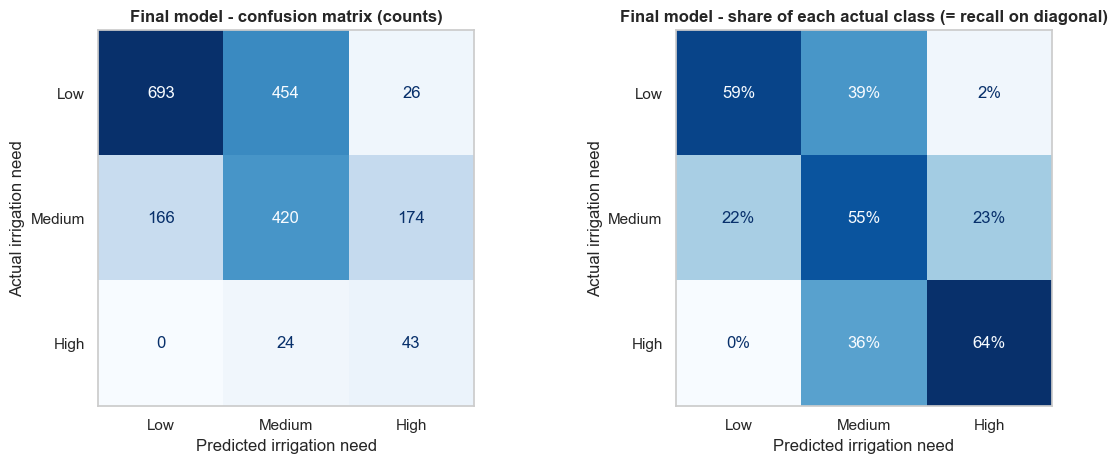

Trivial baseline (always predict 'Low') accuracy: 0.587
Final model accuracy: 0.578


In [29]:
# One-time confirmation on the untouched test set
final_test_pred = final_pipeline.predict(X_test)
print(f"Final model: {FINAL_NAME}\n")
print(classification_report(y_test, final_test_pred, labels=CLASS_ORDER, digits=3, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
ConfusionMatrixDisplay.from_predictions(y_test, final_test_pred, labels=CLASS_ORDER, cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Final model - confusion matrix (counts)"); axes[0].grid(False)
ConfusionMatrixDisplay.from_predictions(y_test, final_test_pred, labels=CLASS_ORDER, normalize="true", values_format=".0%",
                                        cmap="Blues", ax=axes[1], colorbar=False)
axes[1].set_title("Final model - share of each actual class (= recall on diagonal)"); axes[1].grid(False)
for ax in axes: ax.set_xlabel("Predicted irrigation need"); ax.set_ylabel("Actual irrigation need")
plt.tight_layout(); plt.show()

# Test-set score of the final model vs. a trivial baseline
majority_baseline = (y_test == y_train.mode()[0]).mean()
print(f"Trivial baseline (always predict '{y_train.mode()[0]}') accuracy: {majority_baseline:.3f}")
print(f"Final model accuracy: {accuracy_score(y_test, final_test_pred):.3f}")

# SOft toggle

In [30]:
IRRIGATION_POLICY = {"Low": "Irrigation Not Needed", "Medium": "Irrigation Needed", "High": "Irrigation Needed"}

y_test_binary = y_test.map(IRRIGATION_POLICY)
pred_binary = pd.Series(final_test_pred, index=y_test.index).map(IRRIGATION_POLICY)
print("Pump-decision performance of the final model (test set):")
print(classification_report(y_test_binary, pred_binary, digits=3, zero_division=0))
binary_cm = confusion_matrix(y_test_binary, pred_binary, labels=["Irrigation Not Needed", "Irrigation Needed"])
display(pd.DataFrame(binary_cm, index=["Actual: Not Needed", "Actual: Needed"], columns=["Pred: Not Needed", "Pred: Needed"]))
binary_metrics = classification_report(y_test_binary, pred_binary, output_dict=True, zero_division=0)["Irrigation Needed"]

Pump-decision performance of the final model (test set):
                       precision    recall  f1-score   support

    Irrigation Needed      0.579     0.799     0.672       827
Irrigation Not Needed      0.807     0.591     0.682      1173

             accuracy                          0.677      2000
            macro avg      0.693     0.695     0.677      2000
         weighted avg      0.713     0.677     0.678      2000



,Pred: Not Needed,Pred: Needed
Actual: Not Needed,693,480
Actual: Needed,166,661


# Feature Importance

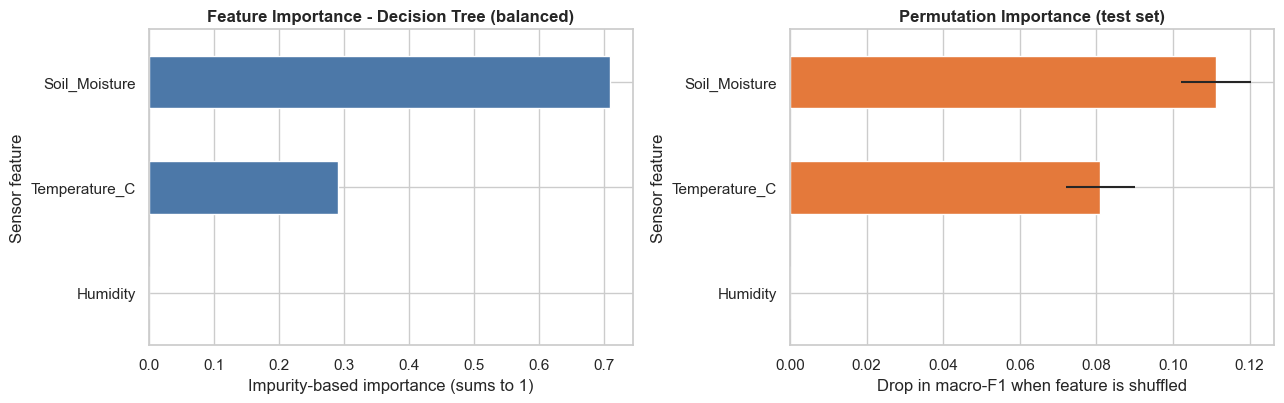

,model_importance,permutation_drop_in_macroF1
Soil_Moisture,0.7094,0.1112
Temperature_C,0.2906,0.0810
Humidity,0.0000,0.0000



Learned decision rules:

|--- Soil_Moisture <= 24.98
|   |--- Temperature_C <= 30.06
|   |   |--- class: Medium
|   |--- Temperature_C >  30.06
|   |   |--- class: High
|--- Soil_Moisture >  24.98
|   |--- Temperature_C <= 30.16
|   |   |--- class: Low
|   |--- Temperature_C >  30.16
|   |   |--- class: Medium



In [31]:
clf = final_pipeline.named_steps["clf"]
if hasattr(clf, "feature_importances_"):
    internal = pd.Series(clf.feature_importances_, index=FEATURES)
    internal_label = "Impurity-based importance (sums to 1)"
elif hasattr(clf, "coef_"):
    coef_table = pd.DataFrame(clf.coef_, index=clf.classes_, columns=FEATURES).reindex(CLASS_ORDER)
    print("Logistic-regression coefficients on STANDARDISED features (per class, log-odds per 1 std):")
    display(coef_table.round(3))
    internal = coef_table.abs().mean()
    internal_label = "Mean |coefficient| across classes (standardised features)"

perm = permutation_importance(final_pipeline, X_test, y_test, scoring="f1_macro", n_repeats=30, random_state=RANDOM_STATE)
perm_df = pd.DataFrame({"mean": perm.importances_mean, "std": perm.importances_std}, index=FEATURES)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
internal.sort_values().plot(kind="barh", ax=axes[0], color="#4C78A8")
axes[0].set_title(f"Feature Importance - {FINAL_NAME}"); axes[0].set_xlabel(internal_label); axes[0].set_ylabel("Sensor feature")
perm_df["mean"].sort_values().plot(kind="barh", xerr=perm_df.loc[perm_df["mean"].sort_values().index, "std"], ax=axes[1], color="#E4793B")
axes[1].set_title("Permutation Importance (test set)"); axes[1].set_xlabel("Drop in macro-F1 when feature is shuffled"); axes[1].set_ylabel("Sensor feature")
plt.tight_layout(); plt.show()
display(pd.DataFrame({"model_importance": internal, "permutation_drop_in_macroF1": perm_df["mean"]}).round(4))

if isinstance(clf, DecisionTreeClassifier):
    print("\nLearned decision rules:\n")
    print(export_text(clf, feature_names=FEATURES, max_depth=4))